In [3]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
from stock_simulator import gbm

In [ ]:
def rolling_volatility(prices, window_size, path=0, annualize=True):
    '''Calculate rolling volatility for a given price series.
    Parameters:
    prices: dataframe of price data
    window_size: int, size of the rolling window
    path: int, index of the path to analyze (for multi-path data) using first path by default
    annualize: bool, whether to annualize the volatility
    Returns:
    pandas Series of rolling volatility values
    ''' 
    if path is not None and (path < 0 or path >= (prices.shape[1] - 1)):
        raise ValueError("Path index out of bounds.")
    if path is not None:
        prices = prices[f"Path_{path}"].values.reshape(-1, 1)
    price_series = pd.Series(np.diff(np.log(prices),axis=0).flatten())
    volatility = price_series.rolling(window_size).std() * np.sqrt(252)
    if not annualize:
        volatility /= np.sqrt(252)
    return volatility

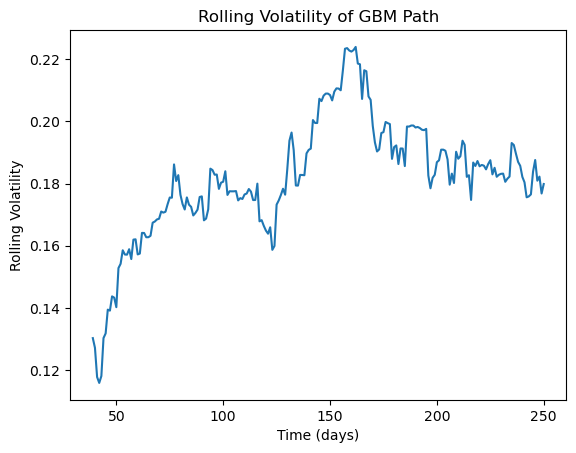

In [63]:
#Create a sample path of the geometric brownian motion to calculate the rolling volatility
#gbm_paths = gbm(n_paths=3)
rolling_volatility_values = rolling_volatility(gbm_paths, window_size=40)
plt.plot(gbm_paths.index[:-1], rolling_volatility_values)
plt.title("Rolling Volatility of GBM Path") 
plt.xlabel("Time (days)")
plt.ylabel("Rolling Volatility")
plt.show()

In [15]:
rolling_volatility_values

Series([], dtype: float64)

In [34]:
prices =gbm_paths["Path_2"].values.reshape(-1, 1)

In [31]:
np.diff(np.log(prices)).max

<function ndarray.max>

In [38]:
np.diff(np.log(prices),axis=0)[:10]

array([[-0.00263239],
       [-0.00559736],
       [-0.00555018],
       [-0.02141446],
       [ 0.0042766 ],
       [ 0.0187829 ],
       [-0.01763268],
       [-0.0141837 ],
       [-0.00335754],
       [ 0.00014741]])

In [37]:
np.log(prices)[:10]

array([[4.61333029],
       [4.61069791],
       [4.60510055],
       [4.59955036],
       [4.5781359 ],
       [4.58241251],
       [4.6011954 ],
       [4.58356272],
       [4.56937903],
       [4.56602149]])

In [35]:
prices.shape

(252, 1)

In [56]:
None == 0

False